In [3]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version PyTorch was built with: {torch.version.cuda}")
print(f"Is CUDA available: {torch.cuda.is_available()}")


PyTorch version: 2.4.0+cu118
CUDA version PyTorch was built with: 11.8
Is CUDA available: True


In [4]:
!pip install ultralytics kaggle opencv-python matplotlib pillow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.7 MB/s eta 0:00:00


In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [6]:
import os

BASE_PATH = "/kaggle/input/datasets/hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection"

print(os.listdir(BASE_PATH))

['0Val_via_annos.json', 'validation', '0Train_via_annos.json', 'image']


In [7]:
WORK_DIR = "/kaggle/working/dataset"

os.makedirs(f"{WORK_DIR}/images/train", exist_ok=True)
os.makedirs(f"{WORK_DIR}/images/val", exist_ok=True)
os.makedirs(f"{WORK_DIR}/labels/train", exist_ok=True)
os.makedirs(f"{WORK_DIR}/labels/val", exist_ok=True)

print("✅ Working dirs ready")

✅ Working dirs ready


In [8]:
import shutil

train_src = os.path.join(BASE_PATH, "image/image")
val_src = os.path.join(BASE_PATH, "validation/validation")

print("Train folder exists:", os.path.exists(train_src))
print("Val folder exists:", os.path.exists(val_src))

for img in os.listdir(train_src):
    shutil.copy(os.path.join(train_src, img), f"{WORK_DIR}/images/train")

for img in os.listdir(val_src):
    shutil.copy(os.path.join(val_src, img), f"{WORK_DIR}/images/val")

print("✅ Images copied")

Train folder exists: True
Val folder exists: True
✅ Images copied


In [9]:
import json
from PIL import Image

def convert_via_to_yolo(json_path, img_folder, label_folder):
    with open(json_path) as f:
        data = json.load(f)

    count, total_boxes = 0, 0

    for filename in data:
        item = data[filename]
        regions = item.get("regions", [])

        img_path = os.path.join(img_folder, filename)
        if not os.path.exists(img_path):
            continue

        img = Image.open(img_path)
        w, h = img.size

        label_file = os.path.join(label_folder, filename.replace(".jpg", ".txt"))
        lines = []

        for region in regions:
            x_points = region.get("all_x", [])
            y_points = region.get("all_y", [])

            if len(x_points) == 0:
                continue

            x_min = max(0, min(x_points))
            x_max = min(w, max(x_points))
            y_min = max(0, min(y_points))
            y_max = min(h, max(y_points))

            bw = (x_max - x_min) / w
            bh = (y_max - y_min) / h

            if bw <= 0 or bh <= 0:
                continue

            x_center = ((x_min + x_max) / 2) / w
            y_center = ((y_min + y_max) / 2) / h

            class_map = {
                "rach": 0,
                "mop_lom": 1,
                "tray_son": 2,
                "mat_bo_phan": 3,
                "vo_kinh": 4,
                "thung": 5
            }

            cls_name = region.get("class", "rach")
            class_id = class_map.get(cls_name, 0)

            lines.append(f"{class_id} {x_center} {y_center} {bw} {bh}")
            total_boxes += 1

        if lines:
            with open(label_file, "w") as f:
                f.write("\n".join(lines))
            count += 1

    print(f"✅ Images with labels: {count}")
    print(f"✅ Total boxes: {total_boxes}")

In [10]:
convert_via_to_yolo(
    os.path.join(BASE_PATH, "0Train_via_annos.json"),
    f"{WORK_DIR}/images/train",
    f"{WORK_DIR}/labels/train"
)

convert_via_to_yolo(
    os.path.join(BASE_PATH, "0Val_via_annos.json"),
    f"{WORK_DIR}/images/val",
    f"{WORK_DIR}/labels/val"
)

✅ Images with labels: 11621
✅ Total boxes: 30044
✅ Images with labels: 2324
✅ Total boxes: 6035


In [11]:
!rm -f /kaggle/working/dataset/labels/train.cache
!rm -f /kaggle/working/dataset/labels/val.cache

In [12]:
data_yaml = f"""
path: {WORK_DIR}
train: images/train
val: images/val

names:
  0: crack
  1: dent
  2: paint_damage
  3: part_damage
  4: glass_damage
  5: hole
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(data_yaml)

print("✅ YAML ready")

✅ YAML ready


In [13]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla P100-PCIE-16GB


In [14]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="/kaggle/working/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    device=0   
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.34 🚀 Python-3.12.12 torch-2.4.0+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79db8e703890>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [15]:
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

In [19]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from PIL import Image
import glob

all_images = glob.glob("dataset/images/val/*.jpg")

valid_images = []

for img_path in all_images:
    try:
        img = Image.open(img_path)
        img.verify()   # check corruption
        valid_images.append(img_path)
    except:
        continue

print("Valid images:", len(valid_images))

Valid images: 2324


In [26]:
batch_size = 100

for i in range(0, len(valid_images), batch_size):
    batch = valid_images[i:i+batch_size]

    for _ in model.predict(
        source=batch,
        conf=0.2,
        imgsz=512,
        stream=True,
        verbose=False
    ):
        pass

---- Image Result ----
crack | severe | wheel / bumper
crack | severe | rear
paint_damage | minor | wheel / bumper


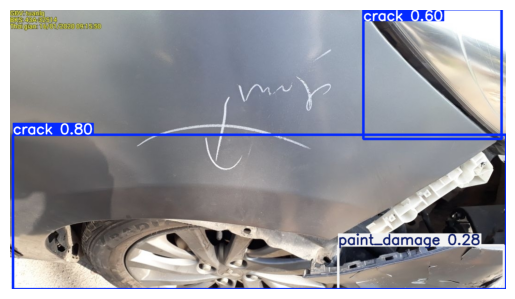

---- Image Result ----
crack | severe | wheel / bumper
crack | severe | wheel / bumper


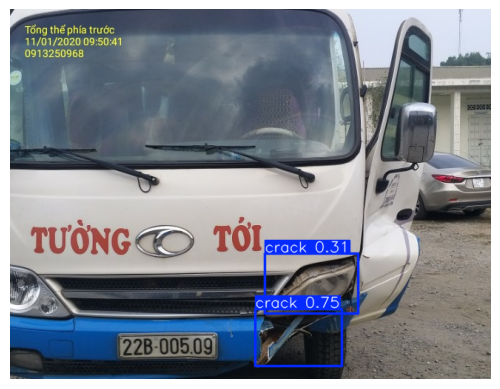

---- Image Result ----
part_damage | moderate | door / side


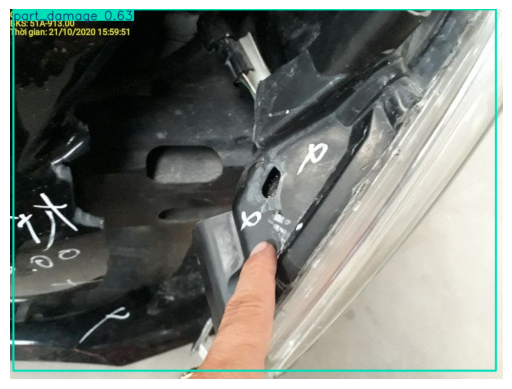

---- Image Result ----
dent | moderate | door / side


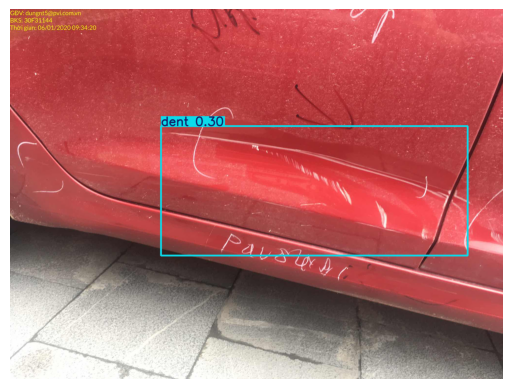

---- Image Result ----
hole | moderate | rear
crack | severe | rear
crack | severe | door / side
crack | severe | door / side
dent | moderate | door / side


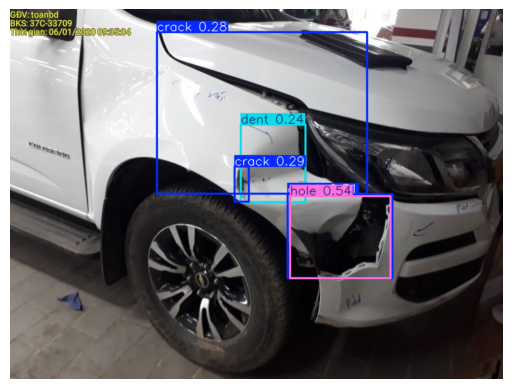

---- Image Result ----


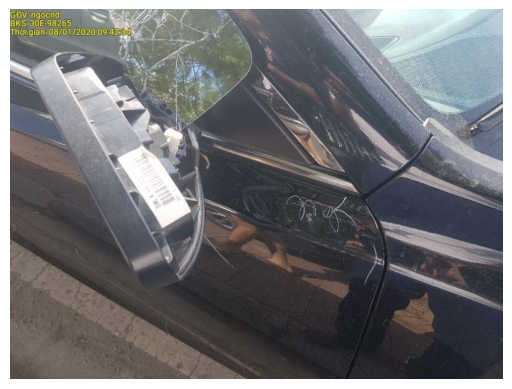

---- Image Result ----


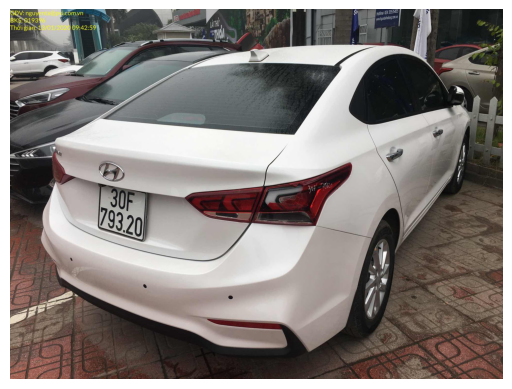

---- Image Result ----
paint_damage | minor | door / side


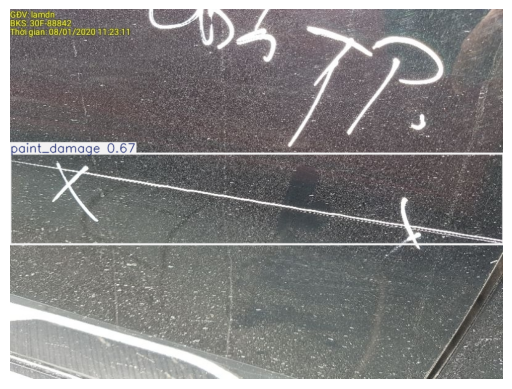

---- Image Result ----


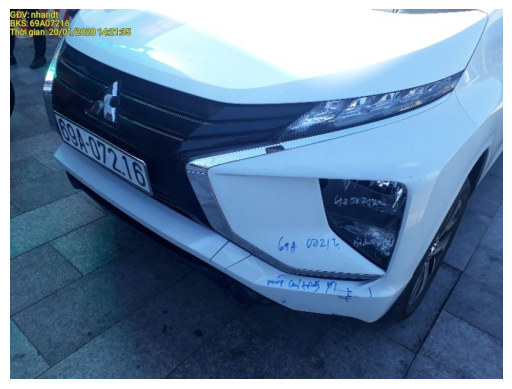

---- Image Result ----
hole | moderate | door / side
paint_damage | minor | rear
paint_damage | minor | door / side


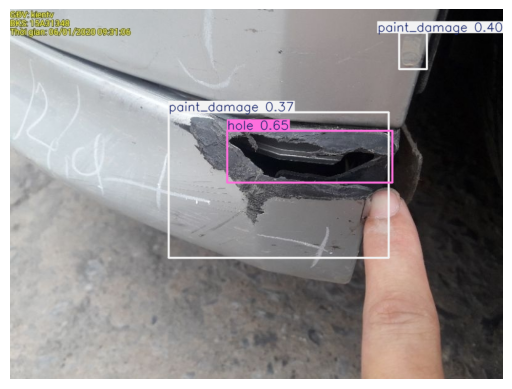

In [22]:
import cv2
import matplotlib.pyplot as plt

def get_car_part(box, img):
    h, w = img.shape[:2]
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    if cx < w * 0.33:
        horizontal = "front"
    elif cx > w * 0.66:
        horizontal = "rear"
    else:
        horizontal = "middle"

    if cy > h * 0.7:
        return "wheel / bumper"
    elif horizontal == "front":
        return "front"
    elif horizontal == "rear":
        return "rear"
    else:
        return "door / side"


def get_severity(label):
    if label in ["crack", "glass_damage"]:
        return "severe"
    elif label in ["dent", "hole"]:
        return "moderate"
    elif label in ["paint_damage"]:
        return "minor"
    else:
        return "moderate"


# show only few images (important)
count = 0

for r in results:
    if r.boxes is None:
        continue

    img = r.plot()

    print("---- Image Result ----")

    for box in r.boxes:
        cls = int(box.cls[0])
        label = model.names[cls]

        severity = get_severity(label)
        part = get_car_part(box, r.orig_img)

        print(f"{label} | {severity} | {part}")

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    count += 1
    if count == 10:   # 🔥 limit display
        break

In [23]:
import os

os.makedirs("final_outputs", exist_ok=True)

count = 0

for r in results:
    if r.boxes is None:
        continue

    img = r.plot()

    save_path = f"final_outputs/result_{count}.jpg"
    cv2.imwrite(save_path, img)

    count += 1
    if count == 10:
        break

print("✅ Saved demo images")

✅ Saved demo images


(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

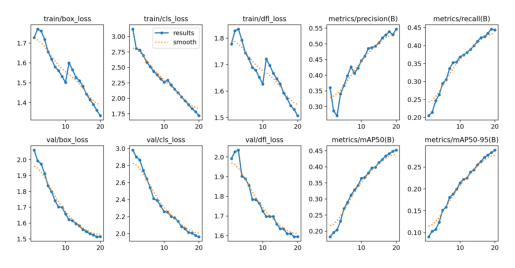

In [24]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/train/results.png")
plt.imshow(img)
plt.axis('off')

In [25]:
summary = []

for r in results:
    if r.boxes is None:
        continue

    for box in r.boxes:
        cls = int(box.cls[0])
        label = model.names[cls]

        severity = get_severity(label)
        part = get_car_part(box, r.orig_img)

        summary.append((label, severity, part))

print(summary[:10])

[('crack', 'severe', 'wheel / bumper'), ('crack', 'severe', 'rear'), ('paint_damage', 'minor', 'wheel / bumper'), ('crack', 'severe', 'wheel / bumper'), ('crack', 'severe', 'wheel / bumper'), ('part_damage', 'moderate', 'door / side'), ('dent', 'moderate', 'door / side'), ('hole', 'moderate', 'rear'), ('crack', 'severe', 'rear'), ('crack', 'severe', 'door / side')]
